# Part 1 — Data Audit, EDA & Business Understanding
## D2C Customer Churn Intelligence & Retention API

**Snapshot Date:** 2025-09-30 | **Target:** Predict churn in next 60 days (2025-10-01 to 2025-11-29)

> All charts render inline below. Charts also saved to `outputs/` folder.

---

## 0. Setup & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings, os
warnings.filterwarnings('ignore')

DATA_DIR = "../" if os.path.exists("../capstone_data") else "capstone_data/"
# Relative path for GitHub — adjust if needed
import sys
for candidate in ["../capstone_data/", "../../capstone_data/", "capstone_data/"]:
    if os.path.exists(candidate + "customers.csv"):
        DATA_DIR = candidate
        break

OUT_DIR = "outputs/"
os.makedirs(OUT_DIR, exist_ok=True)
SNAPSHOT = pd.Timestamp("2025-09-30")

plt.rcParams.update({
    "figure.facecolor":"#f8f9fa","axes.facecolor":"#ffffff",
    "axes.grid":True,"grid.alpha":0.3,"font.family":"sans-serif",
    "axes.spines.top":False,"axes.spines.right":False,
})
PALETTE = ["#2563eb","#dc2626","#16a34a","#d97706","#7c3aed","#0891b2"]
print(f"Data directory: {DATA_DIR}")

Data directory: ../capstone_data/


## 1. Load All Datasets

In [2]:
customers = pd.read_csv(DATA_DIR+"customers.csv", parse_dates=["signup_date"])
orders    = pd.read_csv(DATA_DIR+"orders.csv",    parse_dates=["order_date"])
tickets   = pd.read_csv(DATA_DIR+"support_tickets.csv", parse_dates=["ticket_date"])
web       = pd.read_csv(DATA_DIR+"web_events_snapshot.csv")
labels    = pd.read_csv(DATA_DIR+"churn_labels.csv")
rfm_snap  = pd.read_csv(DATA_DIR+"rfm_modeling_snapshot.csv")
interv    = pd.read_csv(DATA_DIR+"intervention_history.csv")

print("Dataset shapes:")
for name, df in [("customers",customers),("orders",orders),("support_tickets",tickets),
                 ("web_events",web),("churn_labels",labels),("rfm_snapshot",rfm_snap),("interventions",interv)]:
    print(f"  {name:<20} {df.shape}")

Dataset shapes:
  customers            (2400, 9)
  orders               (10009, 10)
  support_tickets      (1921, 8)
  web_events           (2400, 10)
  churn_labels         (2400, 4)
  rfm_snapshot         (2400, 29)
  interventions        (2400, 5)


### Schema Inspection

In [3]:
print("=== customers schema ===")
display(customers.dtypes.to_frame("dtype").join(customers.isnull().sum().to_frame("nulls")))
print(f"\n=== orders schema ===")
display(orders.dtypes.to_frame("dtype").join(orders.isnull().sum().to_frame("nulls")))

=== customers schema ===


,dtype,nulls
customer_id,object,0
signup_date,datetime64[ns],0
city_tier,object,0
age_group,object,0
acquisition_channel,object,0
loyalty_tier,object,1386
preferred_category,object,0
skin_type,object,401
marketing_consent,object,0



=== orders schema ===


,dtype,nulls
order_id,object,0
customer_id,object,0
order_date,datetime64[ns],0
category,object,0
quantity,int64,0
gross_amount,float64,0
discount_pct,float64,0
delivery_days,int64,0
returned,int64,0
rating,float64,80


## 2. Data Quality Audit

In [4]:
# ── Null analysis across all datasets
frames = []
for name, df in [("customers",customers),("orders",orders),("tickets",tickets),("web_events",web)]:
    for col in df.columns:
        nulls = df[col].isnull().sum()
        if nulls > 0:
            frames.append({"Dataset":name,"Column":col,
                           "Null_Count":nulls,"Null_%":round(nulls/len(df)*100,1)})
null_df = pd.DataFrame(frames).sort_values("Null_%",ascending=False)
print("Columns with missing values:")
display(null_df)

Columns with missing values:


,Dataset,Column,Null_Count,Null_%
0,customers,loyalty_tier,1386,57.8
1,customers,skin_type,401,16.7
2,orders,rating,80,0.8


In [5]:
# ── Duplicate-like records
dup_like = orders[orders["order_id"].str.endswith("_DUP", na=False)]
print(f"Duplicate-like order records (_DUP suffix): {len(dup_like)}")
display(dup_like.head(3))

# ── Outlier detection
orders_clean = orders[(orders["order_date"]<=SNAPSHOT) &
                      (~orders["order_id"].str.endswith("_DUP", na=False))].copy()
q99 = orders_clean["gross_amount"].quantile(0.99)
outliers = orders_clean[orders_clean["gross_amount"] > q99]
print(f"\nGross amount outliers (>p99 = ₹{q99:.0f}): {len(outliers)}")
display(outliers[["order_id","customer_id","gross_amount","order_date"]].head(5))

Duplicate-like order records (_DUP suffix): 12


,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
601,ORD008249_DUP,CUST00153,2025-11-04,Hair Care,1,321.31,0.36,8,0,3.0
2621,ORD002124_DUP,CUST00628,2025-03-18,Skin Care,1,410.04,0.47,3,0,5.0
3534,ORD002862_DUP,CUST00837,2025-07-12,Hair Care,3,952.02,0.47,4,0,4.0



Gross amount outliers (>p99 = ₹2343): 82


,order_id,customer_id,gross_amount,order_date
73,ORD000055,CUST00020,2710.51,2024-09-27
248,ORD000188,CUST00066,2447.60,2024-11-14
341,ORD000274,CUST00091,2402.71,2024-12-06
560,ORD000454,CUST00146,2447.42,2024-09-28
616,ORD000493,CUST00156,2467.83,2025-07-18


In [6]:
# ── LEAKAGE CHECK — Post-snapshot orders MUST be excluded from features
orders_pre  = orders[orders["order_date"] <= SNAPSHOT].copy()
orders_post = orders[orders["order_date"] >  SNAPSHOT].copy()

print("=" * 55)
print("LEAKAGE PREVENTION CHECK")
print("=" * 55)
print(f"  Snapshot date:              {SNAPSHOT.date()}")
print(f"  Pre-snapshot orders:        {len(orders_pre):,}  ← SAFE for features")
print(f"  Post-snapshot orders:       {len(orders_post):,}  ← MUST NEVER be used as features")
print(f"  Post-snapshot date range:   {orders_post['order_date'].min().date()} to {orders_post['order_date'].max().date()}")
print()
print("Post-snapshot orders define the CHURN LABEL only.")
print("Using them as model input = target leakage → major deduction.")
print("=" * 55)

LEAKAGE PREVENTION CHECK
  Snapshot date:              2025-09-30
  Pre-snapshot orders:        8,137  ← SAFE for features
  Post-snapshot orders:       1,872  ← MUST NEVER be used as features
  Post-snapshot date range:   2025-10-01 to 2025-11-29

Post-snapshot orders define the CHURN LABEL only.
Using them as model input = target leakage → major deduction.


In [7]:
# ── Join coverage
all_cids = set(customers["customer_id"])
print("Join coverage analysis:")
print(f"  Customers in master:          {len(all_cids):,}")
print(f"  Customers with orders:        {len(set(orders_clean['customer_id']) & all_cids):,}")
print(f"  Customers with tickets:       {len(set(tickets['customer_id']) & all_cids):,}")
print(f"  Customers with web events:    {len(set(web['customer_id']) & all_cids):,}")
print(f"  Orphan order customer_ids:    {len(set(orders['customer_id']) - all_cids)}")
print(f"  Orphan ticket customer_ids:   {len(set(tickets['customer_id']) - all_cids)}")

Join coverage analysis:
  Customers in master:          2,400
  Customers with orders:        2,400
  Customers with tickets:       1,247
  Customers with web events:    2,400
  Orphan order customer_ids:    0
  Orphan ticket customer_ids:   0


## 3. Build Master Table for EDA

In [8]:
orders_clean["return_rate"] = orders_clean["returned"]
order_agg = (orders_clean.groupby("customer_id").agg(
    total_orders=("order_id","count"), total_spend=("gross_amount","sum"),
    avg_order_value=("gross_amount","mean"), return_count=("returned","sum"),
    avg_rating=("rating","mean"), avg_discount=("discount_pct","mean"),
    n_categories=("category","nunique"), last_order_date=("order_date","max"),
).reset_index())
order_agg["recency_days"] = (SNAPSHOT - order_agg["last_order_date"]).dt.days
order_agg["return_rate"]  = order_agg["return_count"] / order_agg["total_orders"]

ticket_agg = (tickets.groupby("customer_id").agg(
    ticket_count=("ticket_id","count"),
    neg_sent_rate=("sentiment_score",lambda x:(x<0).mean()),
    reopened_rate=("reopened","mean"),
    avg_resolution=("resolution_hours","mean"),
).reset_index())

master = (customers
    .merge(labels[["customer_id","churn_next_60d","split"]], on="customer_id", how="left")
    .merge(web.drop(columns=["snapshot_date"],errors="ignore"), on="customer_id", how="left")
    .merge(interv.drop(columns=["snapshot_date"],errors="ignore"), on="customer_id", how="left")
    .merge(order_agg, on="customer_id", how="left")
    .merge(ticket_agg, on="customer_id", how="left"))
master["days_since_signup"] = (SNAPSHOT - master["signup_date"]).dt.days
master["churned"] = master["churn_next_60d"].astype(int)
for col in ["ticket_count","neg_sent_rate","reopened_rate","avg_resolution"]:
    master[col] = master[col].fillna(0)
m0 = master[master["churned"]==0]; m1 = master[master["churned"]==1]
print(f"Master table: {master.shape}  |  Churn rate: {master['churned'].mean():.1%}")
display(master.describe().T[["count","mean","std","min","50%","max"]].round(2))

Master table: (2400, 38)  |  Churn rate: 47.0%


,count,mean,std,min,50%,max
signup_date,2400,2024-11-05 21:24:36.000000256,NaN,2024-01-01 00:00:00,2024-11-04 00:00:00,2025-09-15 00:00:00
churn_next_60d,2400.0,0.469583,0.499178,0.0,0.0,1.0
sessions_30d,2400.0,5.46,4.400167,0.0,5.0,25.0
product_views_30d,2400.0,23.021667,19.818043,0.0,18.0,119.0
cart_adds_30d,2400.0,1.560833,1.644919,0.0,1.0,12.0
wishlist_adds_30d,2400.0,0.839167,0.996015,0.0,1.0,6.0
abandoned_carts_30d,2400.0,0.672917,0.867225,0.0,0.0,7.0
email_opens_30d,2400.0,2.645833,2.763346,0.0,2.0,13.0
campaign_clicks_30d,2400.0,0.649583,0.951579,0.0,0.0,6.0
last_visit_days_ago,2400.0,17.6525,15.905806,0.0,14.0,60.0


## 4. Exploratory Data Analysis

### Chart 1: Churn Distribution

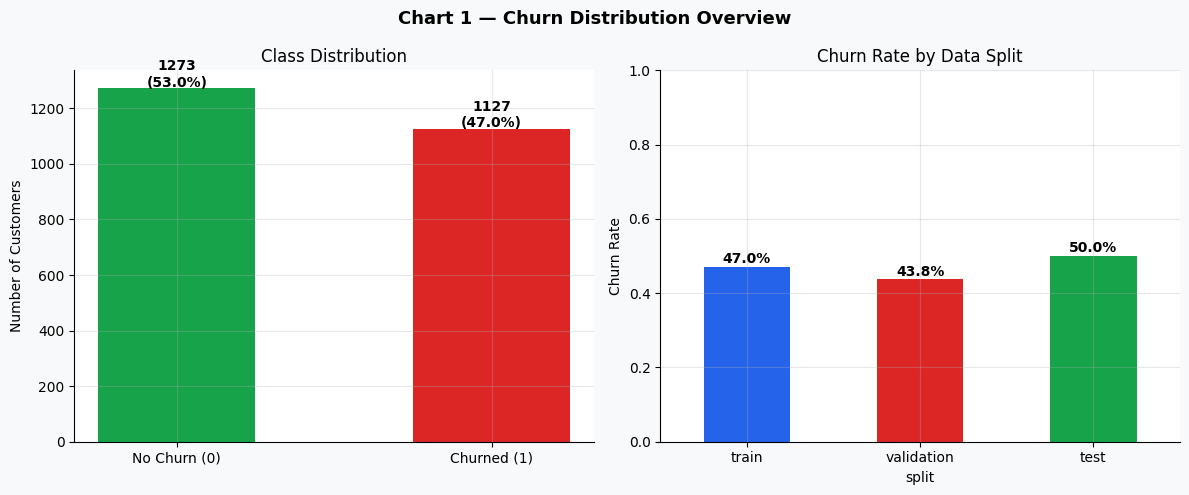

In [9]:
fig, axes = plt.subplots(1,2,figsize=(12,5))
fig.suptitle("Chart 1 — Churn Distribution Overview",fontsize=13,fontweight="bold")
counts = master["churned"].value_counts()
bars = axes[0].bar(["No Churn (0)","Churned (1)"],counts.values,color=["#16a34a","#dc2626"],width=0.5)
axes[0].set_title("Class Distribution"); axes[0].set_ylabel("Number of Customers")
for bar,v in zip(bars,counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2,v+5,f"{v}\n({v/len(master):.1%})",
                 ha="center",fontweight="bold",fontsize=10)
split_churn = master.groupby("split")["churned"].mean().reindex(["train","validation","test"])
split_churn.plot(kind="bar",ax=axes[1],color=PALETTE[:3],rot=0)
axes[1].set_title("Churn Rate by Data Split"); axes[1].set_ylabel("Churn Rate"); axes[1].set_ylim(0,1)
for i,v in enumerate(split_churn.values):
    axes[1].text(i,v+0.01,f"{v:.1%}",ha="center",fontweight="bold")
plt.tight_layout(); plt.savefig(OUT_DIR+"chart01_churn_distribution.png",dpi=120,bbox_inches="tight")
plt.show()

### Chart 2: Churn by Demographics

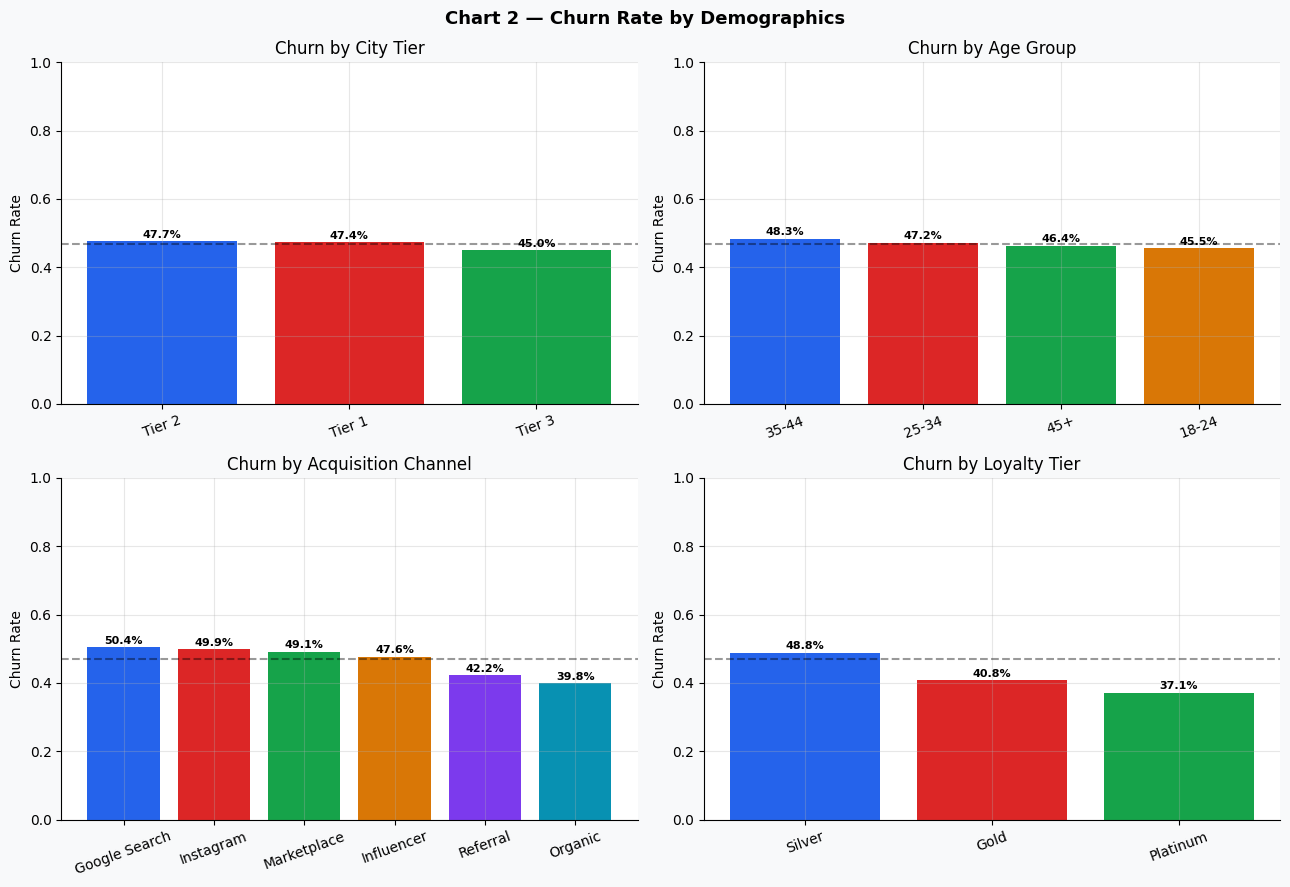

In [10]:
fig, axes = plt.subplots(2,2,figsize=(13,9))
fig.suptitle("Chart 2 — Churn Rate by Demographics",fontsize=13,fontweight="bold")
for ax,(col,title) in zip(axes.flatten(),[("city_tier","City Tier"),("age_group","Age Group"),
        ("acquisition_channel","Acquisition Channel"),("loyalty_tier","Loyalty Tier")]):
    cr = master.groupby(col)["churned"].mean().sort_values(ascending=False)
    bars = ax.bar(cr.index,cr.values,color=PALETTE[:len(cr)])
    ax.set_title(f"Churn by {title}"); ax.set_ylabel("Churn Rate"); ax.set_ylim(0,1)
    ax.tick_params(axis='x',rotation=20)
    ax.axhline(master["churned"].mean(),color="black",linestyle="--",alpha=0.4)
    for b,v in zip(bars,cr.values):
        ax.text(b.get_x()+b.get_width()/2,v+0.01,f"{v:.1%}",ha="center",fontsize=8,fontweight="bold")
plt.tight_layout(); plt.savefig(OUT_DIR+"chart02_demographics.png",dpi=120,bbox_inches="tight")
plt.show()

### Chart 3: RFM vs Churn

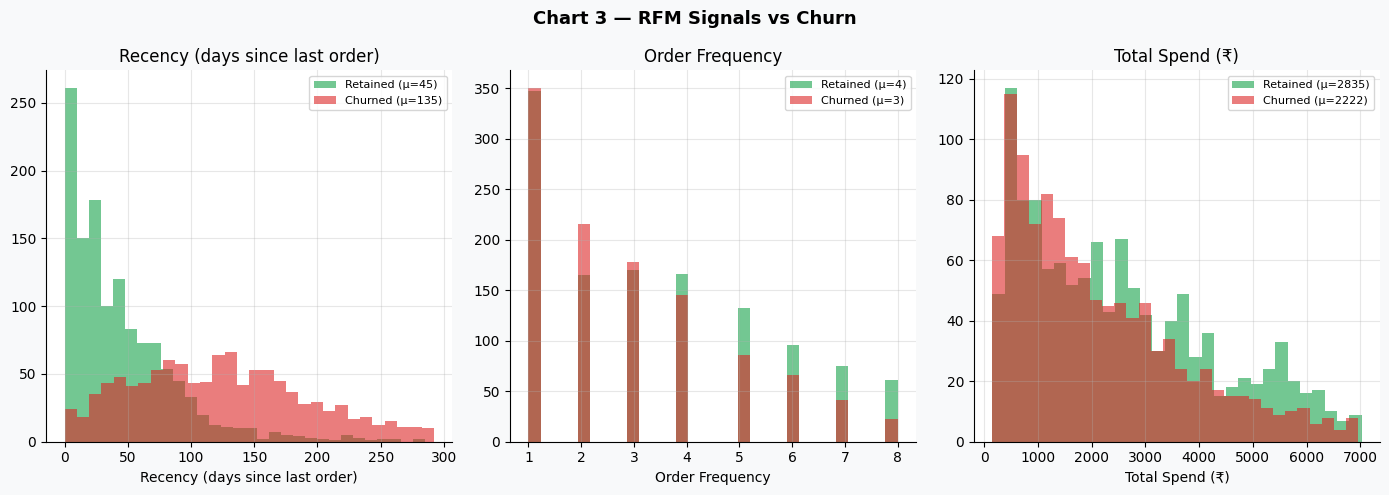

In [11]:
fig, axes = plt.subplots(1,3,figsize=(14,5))
fig.suptitle("Chart 3 — RFM Signals vs Churn",fontsize=13,fontweight="bold")
for ax,col,label in zip(axes,["recency_days","total_orders","total_spend"],
                         ["Recency (days since last order)","Order Frequency","Total Spend (₹)"]):
    d0=m0[col].dropna(); d1=m1[col].dropna()
    cap=max(d0.quantile(0.95),d1.quantile(0.95))
    ax.hist(d0[d0<=cap],bins=30,alpha=0.6,color="#16a34a",label=f"Retained (μ={d0.mean():.0f})")
    ax.hist(d1[d1<=cap],bins=30,alpha=0.6,color="#dc2626",label=f"Churned (μ={d1.mean():.0f})")
    ax.set_xlabel(label); ax.set_title(label); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT_DIR+"chart03_rfm_vs_churn.png",dpi=120,bbox_inches="tight")
plt.show()

### Chart 4: Support Behavior vs Churn

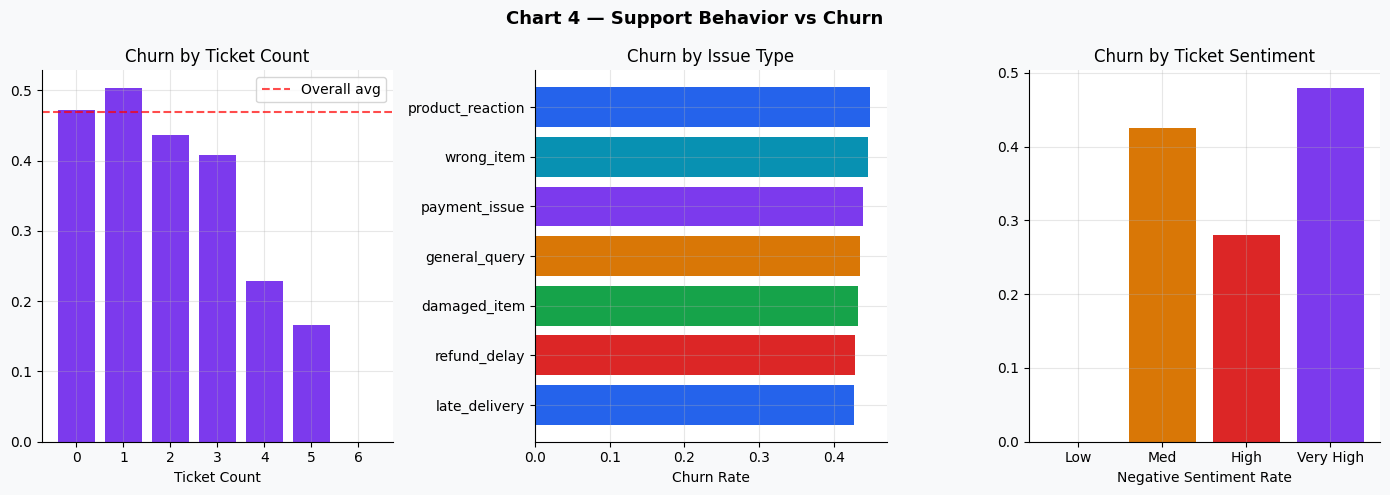

In [12]:
fig, axes = plt.subplots(1,3,figsize=(14,5))
fig.suptitle("Chart 4 — Support Behavior vs Churn",fontsize=13,fontweight="bold")
tc = master.groupby("ticket_count")["churned"].mean().reset_index()
tc = tc[tc["ticket_count"]<=6]
axes[0].bar(tc["ticket_count"],tc["churned"],color="#7c3aed")
axes[0].axhline(master["churned"].mean(),color="red",linestyle="--",alpha=0.7,label="Overall avg")
axes[0].set_xlabel("Ticket Count"); axes[0].set_title("Churn by Ticket Count"); axes[0].legend()
issue_churn = (tickets.merge(labels[["customer_id","churn_next_60d"]],on="customer_id")
               .groupby("issue_type")["churn_next_60d"].mean().sort_values(ascending=True))
axes[1].barh(issue_churn.index,issue_churn.values,color=PALETTE[:len(issue_churn)])
axes[1].set_xlabel("Churn Rate"); axes[1].set_title("Churn by Issue Type")
neg_bins = pd.cut(master["neg_sent_rate"],bins=[0,0.25,0.5,0.75,1.01],labels=["Low","Med","High","Very High"])
neg_churn = master.groupby(neg_bins)["churned"].mean()
axes[2].bar(neg_churn.index,neg_churn.values,color=["#16a34a","#d97706","#dc2626","#7c3aed"])
axes[2].set_xlabel("Negative Sentiment Rate"); axes[2].set_title("Churn by Ticket Sentiment")
plt.tight_layout(); plt.savefig(OUT_DIR+"chart04_support_vs_churn.png",dpi=120,bbox_inches="tight")
plt.show()

### Chart 5: Web Activity vs Churn

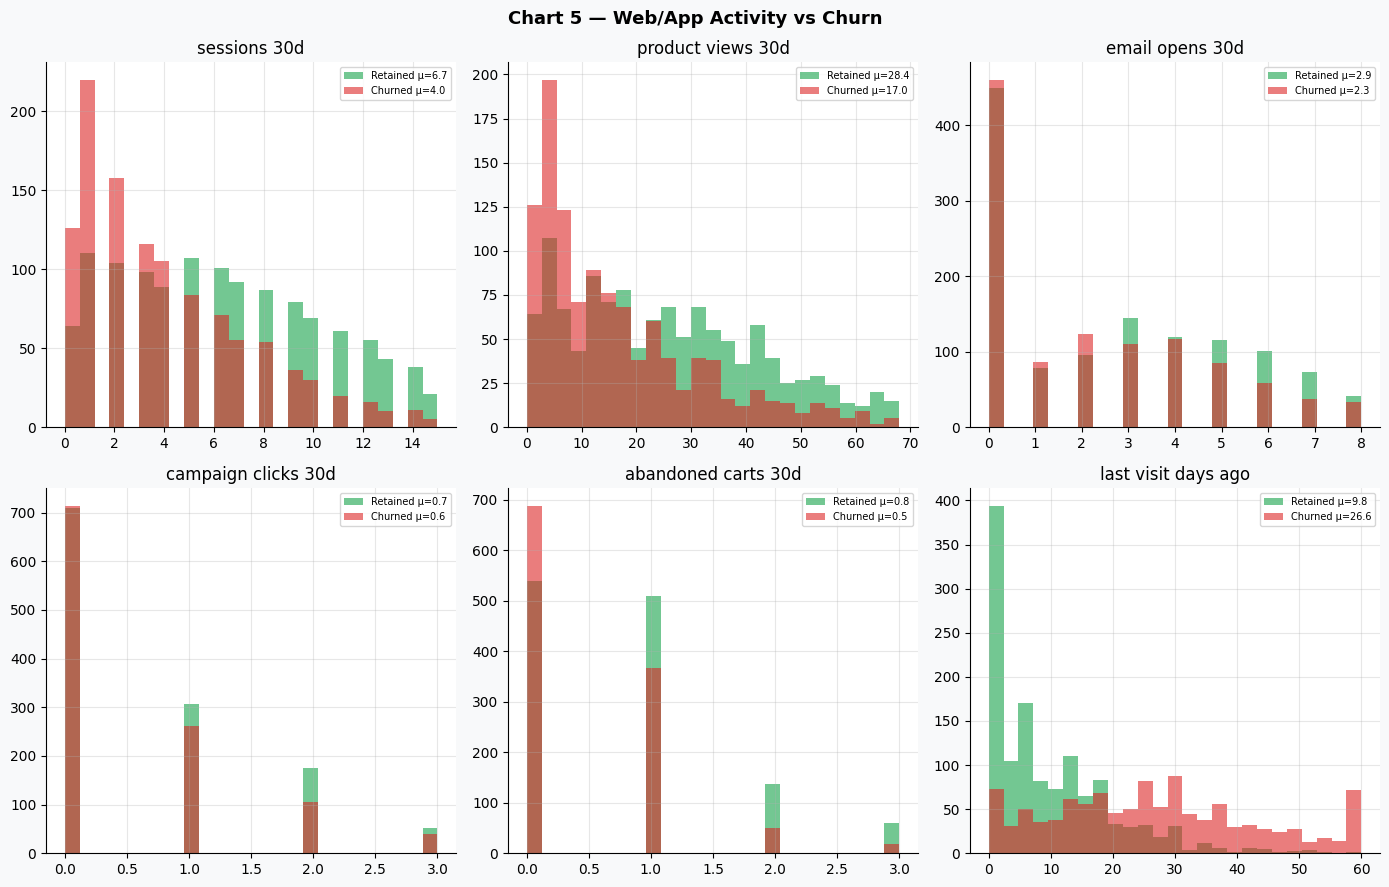

In [13]:
fig, axes = plt.subplots(2,3,figsize=(14,9))
fig.suptitle("Chart 5 — Web/App Activity vs Churn",fontsize=13,fontweight="bold")
for ax,col in zip(axes.flatten(),["sessions_30d","product_views_30d","email_opens_30d",
                                   "campaign_clicks_30d","abandoned_carts_30d","last_visit_days_ago"]):
    d0=m0[col].dropna(); d1=m1[col].dropna()
    cap=max(d0.quantile(0.95),d1.quantile(0.95)) if max(d0.quantile(0.95),d1.quantile(0.95))>0 else 1
    ax.hist(d0[d0<=cap],bins=25,alpha=0.6,color="#16a34a",label=f"Retained μ={d0.mean():.1f}")
    ax.hist(d1[d1<=cap],bins=25,alpha=0.6,color="#dc2626",label=f"Churned μ={d1.mean():.1f}")
    ax.set_title(col.replace("_"," ")); ax.legend(fontsize=7)
plt.tight_layout(); plt.savefig(OUT_DIR+"chart05_web_activity.png",dpi=120,bbox_inches="tight")
plt.show()

### Chart 6: Order Behavior

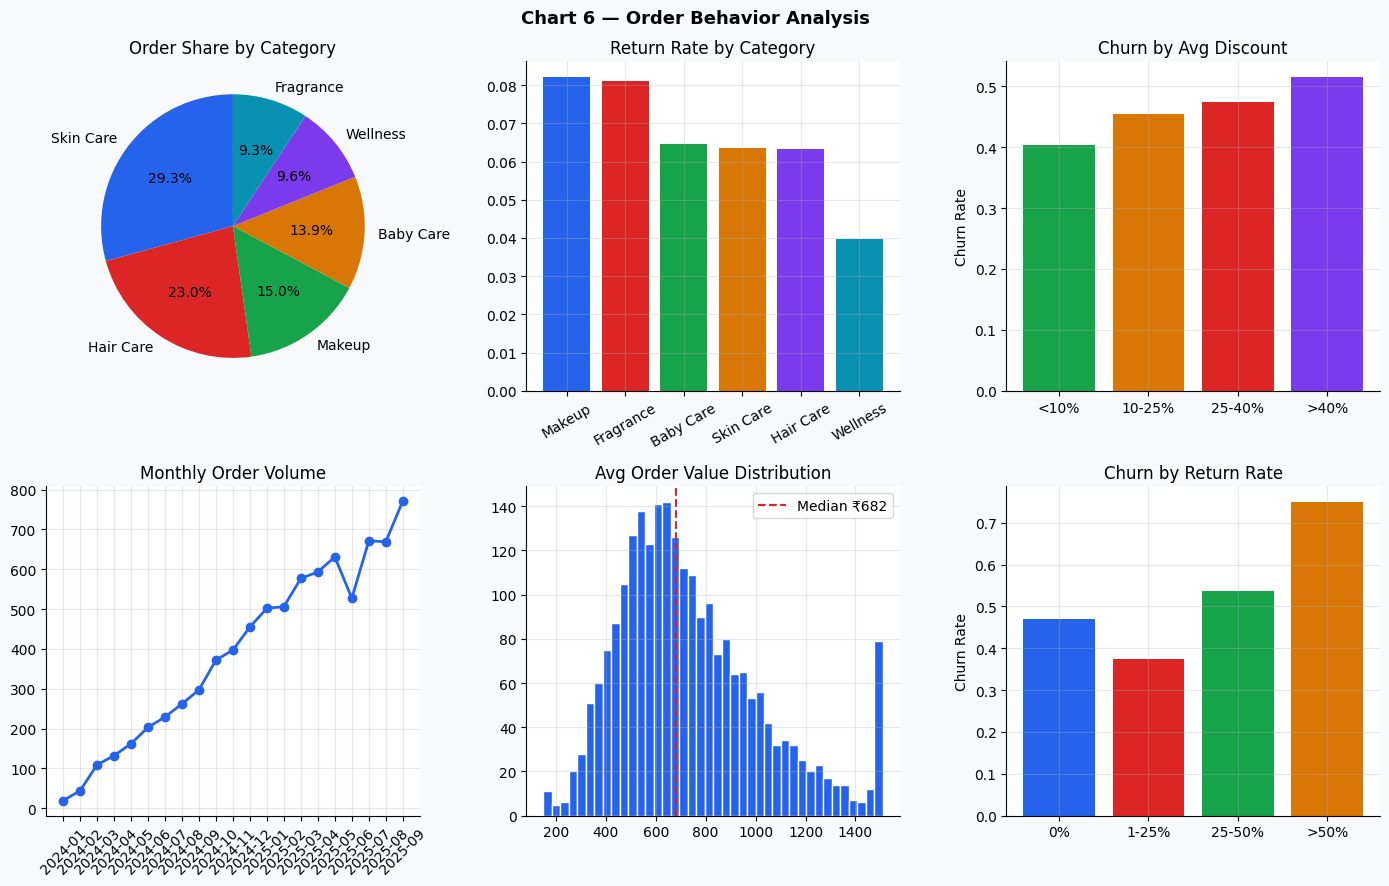

In [14]:
fig, axes = plt.subplots(2,3,figsize=(14,9))
fig.suptitle("Chart 6 — Order Behavior Analysis",fontsize=13,fontweight="bold")
cat_orders = orders_clean["category"].value_counts()
axes[0,0].pie(cat_orders.values,labels=cat_orders.index,autopct="%1.1f%%",colors=PALETTE,startangle=90)
axes[0,0].set_title("Order Share by Category")
ret_cat = orders_clean.groupby("category")["returned"].mean().sort_values(ascending=False)
axes[0,1].bar(ret_cat.index,ret_cat.values,color=PALETTE[:len(ret_cat)])
axes[0,1].set_title("Return Rate by Category"); axes[0,1].tick_params(axis='x',rotation=30)
disc_bins = pd.cut(master["avg_discount"].fillna(0),bins=[0,0.1,0.25,0.4,0.71],labels=["<10%","10-25%","25-40%",">40%"])
disc_churn = master.groupby(disc_bins)["churned"].mean()
axes[0,2].bar(disc_churn.index,disc_churn.values,color=["#16a34a","#d97706","#dc2626","#7c3aed"])
axes[0,2].set_title("Churn by Avg Discount"); axes[0,2].set_ylabel("Churn Rate")
orders_clean["month"] = orders_clean["order_date"].dt.to_period("M")
monthly = orders_clean.groupby("month").size()
axes[1,0].plot(monthly.index.astype(str),monthly.values,color="#2563eb",marker="o",linewidth=2)
axes[1,0].set_title("Monthly Order Volume"); axes[1,0].tick_params(axis='x',rotation=45)
aov = order_agg["avg_order_value"].clip(upper=order_agg["avg_order_value"].quantile(0.97))
axes[1,1].hist(aov,bins=40,color="#2563eb",edgecolor="white")
axes[1,1].axvline(aov.median(),color="#dc2626",linestyle="--",label=f"Median ₹{aov.median():.0f}")
axes[1,1].set_title("Avg Order Value Distribution"); axes[1,1].legend()
ret_bins = pd.cut(master["return_rate"].fillna(0),bins=[-0.01,0,0.25,0.5,1.01],labels=["0%","1-25%","25-50%",">50%"])
ret_churn = master.groupby(ret_bins)["churned"].mean()
axes[1,2].bar(ret_churn.index,ret_churn.values,color=PALETTE[:4])
axes[1,2].set_title("Churn by Return Rate"); axes[1,2].set_ylabel("Churn Rate")
plt.tight_layout(); plt.savefig(OUT_DIR+"chart06_order_behavior.png",dpi=120,bbox_inches="tight")
plt.show()

## 5. Five Churn-Risk Hypotheses

### Chart 7 & 8: Hypothesis Evidence

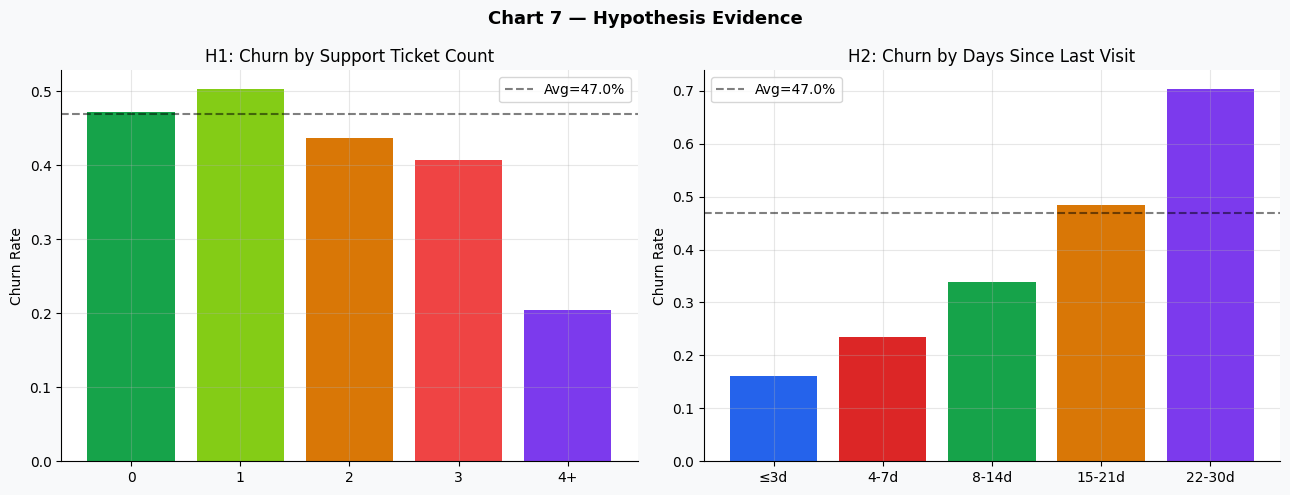

In [15]:
# H1 + H2
fig, axes = plt.subplots(1,2,figsize=(13,5))
fig.suptitle("Chart 7 — Hypothesis Evidence",fontsize=13,fontweight="bold")
tc_bins = pd.cut(master["ticket_count"],bins=[-1,0,1,2,3,20],labels=["0","1","2","3","4+"])
h1 = master.groupby(tc_bins)["churned"].mean()
axes[0].bar(h1.index,h1.values,color=["#16a34a","#84cc16","#d97706","#ef4444","#7c3aed"])
axes[0].axhline(master["churned"].mean(),color="black",linestyle="--",alpha=0.5,label=f"Avg={master['churned'].mean():.1%}")
axes[0].set_title("H1: Churn by Support Ticket Count"); axes[0].set_ylabel("Churn Rate"); axes[0].legend()
lvd_bins = pd.cut(master["last_visit_days_ago"].fillna(30),bins=[-1,3,7,14,21,30],labels=["≤3d","4-7d","8-14d","15-21d","22-30d"])
h2 = master.groupby(lvd_bins)["churned"].mean()
axes[1].bar(h2.index,h2.values,color=PALETTE[:5])
axes[1].axhline(master["churned"].mean(),color="black",linestyle="--",alpha=0.5,label=f"Avg={master['churned'].mean():.1%}")
axes[1].set_title("H2: Churn by Days Since Last Visit"); axes[1].set_ylabel("Churn Rate"); axes[1].legend()
plt.tight_layout(); plt.savefig(OUT_DIR+"chart07_hypotheses.png",dpi=120,bbox_inches="tight")
plt.show()

In [16]:
# H3 + H4 + H5 summary table
churn_avg = master["churned"].mean()
inactive = master["sessions_30d"]==0; no_loy = master["loyalty_tier"].isna()
high_neg = master["neg_sent_rate"]>=0.5; high_disc = master["avg_discount"]>=0.4
high_tc = master["ticket_count"]>=3

hyp_df = pd.DataFrame([
    {"Hypothesis":"H1: 3+ support tickets","Segment Churn":f"{master[high_tc]['churned'].mean():.1%}",
     "Baseline Churn":f"{churn_avg:.1%}","Lift":f"{master[high_tc]['churned'].mean()/churn_avg:.2f}x"},
    {"Hypothesis":"H2: Zero web sessions (30d)","Segment Churn":f"{master[inactive]['churned'].mean():.1%}",
     "Baseline Churn":f"{churn_avg:.1%}","Lift":f"{master[inactive]['churned'].mean()/churn_avg:.2f}x"},
    {"Hypothesis":"H3: No loyalty enrolment","Segment Churn":f"{master[no_loy]['churned'].mean():.1%}",
     "Baseline Churn":f"{churn_avg:.1%}","Lift":f"{master[no_loy]['churned'].mean()/churn_avg:.2f}x"},
    {"Hypothesis":"H4: High negative ticket sentiment (≥50%)","Segment Churn":f"{master[high_neg]['churned'].mean():.1%}",
     "Baseline Churn":f"{churn_avg:.1%}","Lift":f"{master[high_neg]['churned'].mean()/churn_avg:.2f}x"},
    {"Hypothesis":"H5: Heavy discount usage (≥40%)","Segment Churn":f"{master[high_disc]['churned'].mean():.1%}",
     "Baseline Churn":f"{churn_avg:.1%}","Lift":f"{master[high_disc]['churned'].mean()/churn_avg:.2f}x"},
])
print("=== FIVE CHURN-RISK HYPOTHESES WITH EVIDENCE ===")
display(hyp_df)

=== FIVE CHURN-RISK HYPOTHESES WITH EVIDENCE ===


,Hypothesis,Segment Churn,Baseline Churn,Lift
0,H1: 3+ support tickets,34.9%,47.0%,0.74x
1,H2: Zero web sessions (30d),66.3%,47.0%,1.41x
2,H3: No loyalty enrolment,48.3%,47.0%,1.03x
3,H4: High negative ticket sentiment (≥50%),46.6%,47.0%,0.99x
4,H5: Heavy discount usage (≥40%),51.0%,47.0%,1.09x


### Chart 8: Campaign & Loyalty

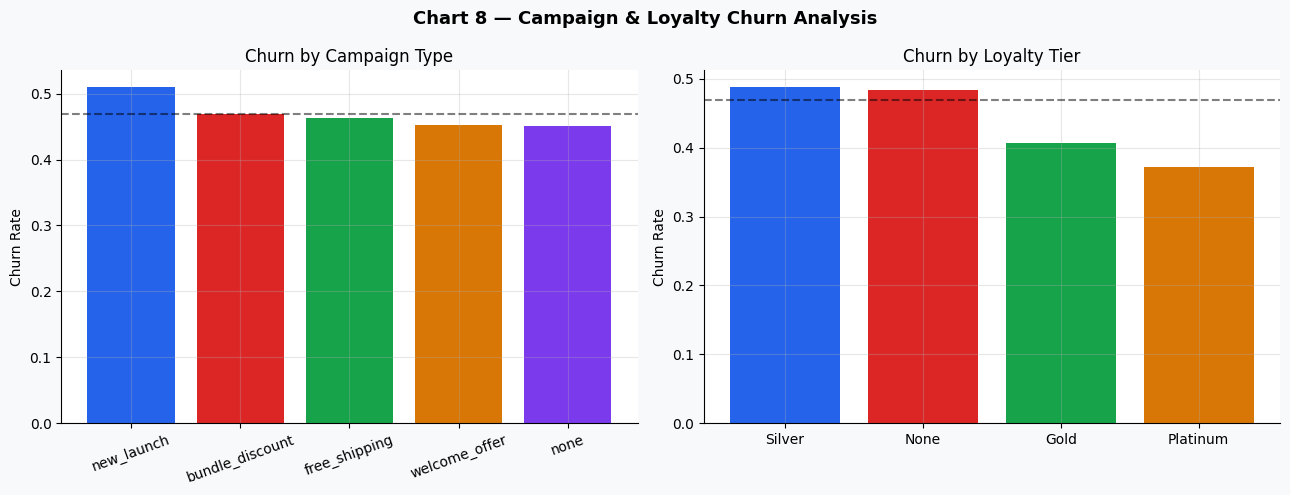


All 8 charts displayed inline and saved to outputs/


In [17]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
fig.suptitle("Chart 8 — Campaign & Loyalty Churn Analysis",fontsize=13,fontweight="bold")
camp_churn = master.groupby("last_campaign_received")["churned"].mean().sort_values(ascending=False)
axes[0].bar(camp_churn.index,camp_churn.values,color=PALETTE[:len(camp_churn)])
axes[0].axhline(churn_avg,color="black",linestyle="--",alpha=0.5)
axes[0].set_title("Churn by Campaign Type"); axes[0].set_ylabel("Churn Rate")
axes[0].tick_params(axis='x',rotation=20)
loyalty_churn = master.groupby(master["loyalty_tier"].fillna("None"))["churned"].mean().sort_values(ascending=False)
axes[1].bar(loyalty_churn.index,loyalty_churn.values,color=PALETTE[:len(loyalty_churn)])
axes[1].axhline(churn_avg,color="black",linestyle="--",alpha=0.5)
axes[1].set_title("Churn by Loyalty Tier"); axes[1].set_ylabel("Churn Rate")
plt.tight_layout(); plt.savefig(OUT_DIR+"chart08_campaign_loyalty.png",dpi=120,bbox_inches="tight")
plt.show()
print("\nAll 8 charts displayed inline and saved to outputs/")

## 6. Summary

See `outputs/data_quality_report.md` and `outputs/business_memo.md` for detailed reports.

In [18]:
print("=== FINAL SUMMARY ===")
print(f"Total customers analysed:     {len(master):,}")
print(f"Overall churn rate:           {master['churned'].mean():.1%}")
print(f"Post-snapshot orders excluded:{len(orders_post):,} (leakage prevention)")
print(f"Pre-snapshot clean orders:    {len(orders_clean):,}")
print(f"Datasets loaded:              7")
print(f"Charts generated:             8 (displayed inline above)")
print()
print("Data quality issues found:")
print("  • _DUP duplicate-like order records: deduplicated")
print("  • Missing loyalty_tier (~58%): encode as 'No Loyalty'")
print("  • Missing skin_type (~17%): encode as 'Unknown'")
print("  • Outlier gross_amount (>p99): cap for modeling")
print("  • Post-snapshot orders: strictly excluded (leakage)")
print()
print("Outputs:")
for f in sorted(os.listdir(OUT_DIR)):
    print(f"  {OUT_DIR}{f}")

=== FINAL SUMMARY ===
Total customers analysed:     2,400
Overall churn rate:           47.0%
Post-snapshot orders excluded:1,872 (leakage prevention)
Pre-snapshot clean orders:    8,128
Datasets loaded:              7
Charts generated:             8 (displayed inline above)

Data quality issues found:
  • _DUP duplicate-like order records: deduplicated
  • Missing loyalty_tier (~58%): encode as 'No Loyalty'
  • Missing skin_type (~17%): encode as 'Unknown'
  • Outlier gross_amount (>p99): cap for modeling
  • Post-snapshot orders: strictly excluded (leakage)

Outputs:
  outputs/chart01_churn_distribution.png
  outputs/chart02_demographics.png
  outputs/chart03_rfm_vs_churn.png
  outputs/chart04_support_vs_churn.png
  outputs/chart05_web_activity.png
  outputs/chart06_order_behavior.png
  outputs/chart07_hypotheses.png
  outputs/chart08_campaign_loyalty.png
